[INFO] Loaded data: rows=639,106, cols=10 in 2.0s
[INFO] Model matrix: rows=639,106, dims=5, mem≈12.8 MB
[INFO] Starting K sweep on subset: 100,000 rows; silhouette sample: 2,000
  [K=2] sweep fit+metrics in 2.4s
  [K=3] sweep fit+metrics in 0.2s
  [K=4] sweep fit+metrics in 0.1s
  [K=5] sweep fit+metrics in 0.2s
  [K=6] sweep fit+metrics in 0.2s
  [K=7] sweep fit+metrics in 0.2s
  [K=8] sweep fit+metrics in 0.2s

== K sweep summary ==
 K  Inertia (subset)  Silhouette (↑, subset 2k)  Davies-Bouldin (↓, subset 2k)  Calinski-Harabasz (↑, subset 2k)
 2       315662.0000                     0.3514                         1.1852                         1078.7074
 3       266027.1250                     0.3282                         1.1077                          820.0600
 4       177352.8594                     0.3710                         0.9094                         1169.6176
 5       150891.5156                     0.3418                         0.8677                         1159.

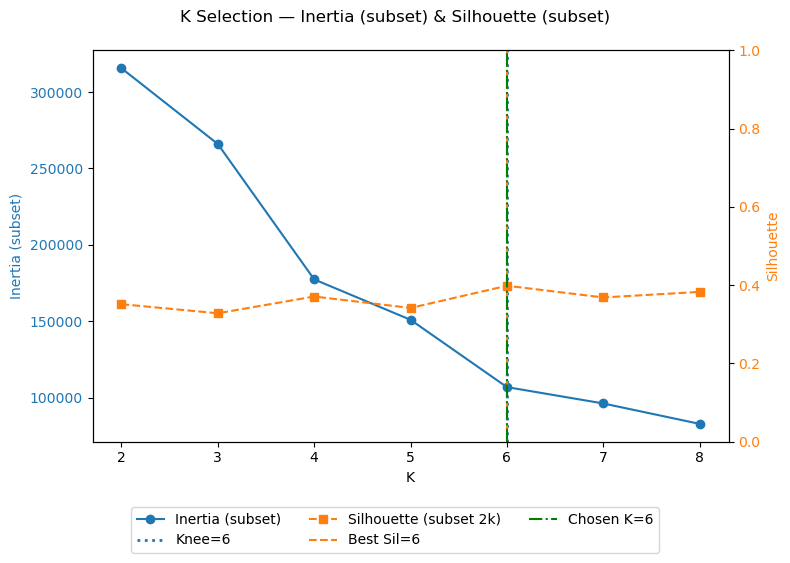

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\k_selection.png
[INFO] Final KMeans fit on full data in 4.8s

[Metrics @ K=6] Silhouette≈0.413 | DBI=0.771 | CH=480647.3


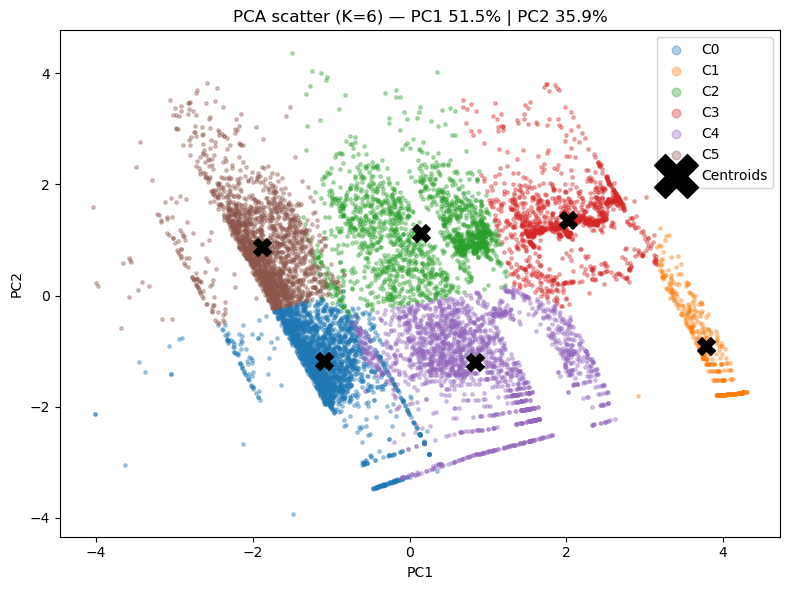

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\pca_scatter.png


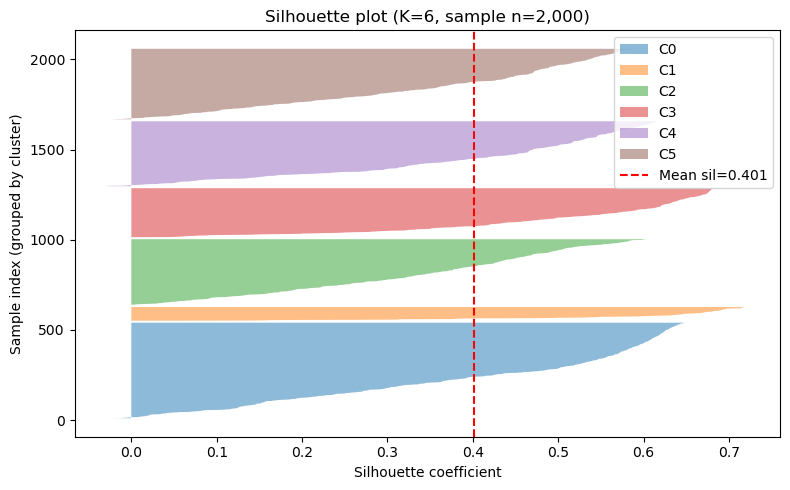

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\silhouette_plot.png
[INFO] Exported clustered dataset to: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering_results.csv

== Cluster sizes ==
 cluster
0    160022
1     26063
2    115168
3     91136
4    124619
5    122098
Name: count, dtype: int64

== Cluster profile (feature means) ==
          usage_total  age_days  since_update_days  usage_per_365  \
cluster                                                            
0              42.73    294.10             131.77          72.12   
1              23.29   3435.04            2678.14           2.44   
2            1570.60    933.32             927.21         705.32   
3            1001.73   2205.20            2172.94         163.66   
4              24.46    823.37             814.97          14.12   
5            2230.85    238.57             115.08        4724.10   

         staleness_ratio  
cluster                  

In [1]:
%%time
# ================================
# Clustering with Fast K-Selection + Sampled Silhouette + PCA Plots
# + DBI/CH metrics + (optional) Stability (ARI) + Rich Profiles
# Tuned for ~639k rows to finish in minutes.
# ================================

# (Optional) Limit BLAS/OpenMP threads to avoid oversubscription.
# Uncomment BEFORE importing numpy/sklearn if you want to cap threads.
# import os as _os
# _os.environ["OMP_NUM_THREADS"] = "4"
# _os.environ["OPENBLAS_NUM_THREADS"] = "4"
# _os.environ["MKL_NUM_THREADS"] = "4"

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)
from sklearn.metrics import adjusted_rand_score

# Try to import KneeLocator; if unavailable, we run without elbow
try:
    from kneed import KneeLocator
    HAVE_KNEE = True
except Exception:
    HAVE_KNEE = False
    print("[WARN] 'kneed' not available; elbow detection will be skipped. Using best silhouette instead.")

# -------------------------------
# 0) Config (EDIT THESE)
# -------------------------------
csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"  # <-- update to your CSV if needed
out_dir  = os.path.dirname(csv_path)

# ===== SPEED MODE for ~639k rows =====
K_min, K_max        = 2, 8          # narrower sweep for speed
sil_sample_size     = 2_000         # silhouette sample size
pca_plot_samples    = 10_000        # points to render in PCA scatter
sil_plot_samples    = 2_000         # points for the silhouette plot (final)
stability_runs      = 0             # 0 to skip; re-enable later if needed
random_state        = 42
choose_k_policy     = "silhouette"  # use "knee" only if kneed is available and you trust inertia on sample

# Whether to also produce a silhouette plot for the chosen K (on a sample)
make_sil_plot       = True

# Extras
save_k_table_csv    = True          # save summary CSV for K sweep
remap_clusters_by   = "usage_per_365"  # or None to skip
export_profiles     = True          # export rich profiles
make_corr_plot      = False         # optional correlation heatmap

# -------------------------------
# 1) Load CSV
# -------------------------------
t0 = time.perf_counter()
df = pd.read_csv(csv_path)

# Required engineered columns from SQL (or compute them in Python beforehand)
required = ["usage_total","age_days","since_update_days","usage_per_365","staleness_ratio"]
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

print(f"[INFO] Loaded data: rows={len(df):,}, cols={df.shape[1]} in {time.perf_counter()-t0:.1f}s")

# -------------------------------
# 2) Build the model matrix
# -------------------------------
X = df[required].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Stabilize skew on usage features
for col in ["usage_total", "usage_per_365"]:
    X[col] = np.log1p(np.clip(X[col].values, 0, None))

# Standardize (float32 to reduce memory)
scaler = StandardScaler()
Xs = scaler.fit_transform(X).astype(np.float32, copy=False)

n, d = Xs.shape
print(f"[INFO] Model matrix: rows={n:,}, dims={d}, mem≈{Xs.nbytes/1e6:.1f} MB")

rng = np.random.default_rng(random_state)

# -------------------------------
# 3) Fast K Sweep on a Subsample
#    - Fit MiniBatchKMeans on a subset (e.g., 50k–100k)
#    - Compute silhouette/DBI/CH on a smaller sample (2k) from that subset
# -------------------------------
t_sweep = time.perf_counter()

# Subsample for the sweep fits
sweep_n  = min(100_000, n)  # tune this to your machine: 50k–100k is usually good
sweep_ix = rng.choice(n, size=sweep_n, replace=False)
Xs_sweep = Xs[sweep_ix]

# Silhouette sample from the sweep subset
sil_n  = min(sil_sample_size, sweep_n)
sil_ix = rng.choice(sweep_n, size=sil_n, replace=False)
X_sil  = Xs_sweep[sil_ix]

Ks        = list(range(K_min, K_max+1))
inertias  = []
silscores = []
dbiscores = []
chiscores = []

print(f"[INFO] Starting K sweep on subset: {sweep_n:,} rows; silhouette sample: {sil_n:,}")
for k in Ks:
    t_k = time.perf_counter()
    mbk = MiniBatchKMeans(
        n_clusters=k,
        n_init=1,            # speed during sweep
        batch_size=8192,     # increase if you have RAM/CPU
        max_iter=50,         # enough to rank Ks
        random_state=random_state
    )
    labels_sweep = mbk.fit_predict(Xs_sweep)
    inertias.append(float(mbk.inertia_))

    lbl_s = labels_sweep[sil_ix]
    if len(np.unique(lbl_s)) > 1:
        silscores.append(float(silhouette_score(X_sil, lbl_s)))
        dbiscores.append(float(davies_bouldin_score(X_sil, lbl_s)))
        chiscores.append(float(calinski_harabasz_score(X_sil, lbl_s)))
    else:
        silscores.append(np.nan); dbiscores.append(np.nan); chiscores.append(np.nan)

    print(f"  [K={k}] sweep fit+metrics in {time.perf_counter()-t_k:.1f}s")

# Elbow (knee) via kneed if available (note: inertia measured on subset)
if HAVE_KNEE:
    kneedle = KneeLocator(Ks, inertias, curve='convex', direction='decreasing')
    k_knee  = int(kneedle.knee) if kneedle.knee is not None else None
else:
    k_knee  = None

# Best K by silhouette on the sample
k_sil_best = Ks[int(np.nanargmax(silscores))]

# Choose K by policy
if choose_k_policy.lower() == "knee" and (k_knee is not None):
    best_k = k_knee
else:
    best_k = k_sil_best

# Resumo tabular da varredura
k_table = pd.DataFrame({
    "K": Ks,
    "Inertia (subset)": inertias,
    "Silhouette (↑, subset 2k)": silscores,
    "Davies-Bouldin (↓, subset 2k)": dbiscores,
    "Calinski-Harabasz (↑, subset 2k)": chiscores
})

print("\n== K sweep summary ==")
print(k_table.round(4).to_string(index=False))

if save_k_table_csv:
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    k_table_csv = os.path.join(out_dir, "k_sweep_summary.csv")
    k_table.to_csv(k_table_csv, index=False, encoding="utf-8")
    print(f"[INFO] Saved K sweep summary: {k_table_csv}")

print(f"\nElbow (knee) on inertia (subset): {k_knee}")
print(f"Best silhouette (subset):         {k_sil_best}")
print(f"Chosen K:                          {best_k}")
print(f"[INFO] K sweep completed in {time.perf_counter()-t_sweep:.1f}s")

# -------------------------------
# 4) Plot + SAVE K-selection figure (elbow + silhouette)
# -------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
color1 = "tab:blue"
ax1.plot(Ks, inertias, "o-", color=color1, label="Inertia (subset)")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia (subset)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(Ks, silscores, "s--", color=color2, label="Silhouette (subset 2k)")
ax2.set_ylabel("Silhouette", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1)

if k_knee is not None:
    ax1.axvline(k_knee, color=color1, ls=":",  lw=2,   label=f"Knee={k_knee}")
ax2.axvline(k_sil_best,  color=color2, ls="--", lw=1.5, label=f"Best Sil={k_sil_best}")
ax2.axvline(best_k,      color="green", ls="-.", lw=1.5, label=f"Chosen K={best_k}")

fig.suptitle("K Selection — Inertia (subset) & Silhouette (subset)")
fig.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
k_png = os.path.join(out_dir, "k_selection.png")
plt.savefig(k_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved: {k_png}")

# -------------------------------
# 5) Fit final KMeans on FULL data (accurate)
# -------------------------------
t_final = time.perf_counter()
kmeans = KMeans(n_clusters=best_k, n_init=5, algorithm='elkan', random_state=random_state)
labels = kmeans.fit_predict(Xs)
df["cluster"] = labels
print(f"[INFO] Final KMeans fit on full data in {time.perf_counter()-t_final:.1f}s")

# Metrics on final labels:
# - Silhouette on a small sample ONLY (quadratic cost)
# - DBI/CH on full data are OK
full_sil_ix = rng.choice(n, size=min(2_000, n), replace=False)
sil_full = float(silhouette_score(Xs[full_sil_ix], labels[full_sil_ix]))
dbi_full = float(davies_bouldin_score(Xs, labels))
chi_full = float(calinski_harabasz_score(Xs, labels))
print(f"\n[Metrics @ K={best_k}] Silhouette≈{sil_full:.3f} | DBI={dbi_full:.3f} | CH={chi_full:.1f}")

# -------------------------------
# 5.1) Optional: Stability (ARI) for chosen K (DISABLED by default)
#        If you enable, consider running on a subset for speed.
# -------------------------------
def kmeans_stability(X, k, runs=5, seed=42, subset_n=100_000):
    rng_local = np.random.default_rng(seed)
    if subset_n is not None and subset_n < X.shape[0]:
        idx = rng_local.choice(X.shape[0], size=subset_n, replace=False)
        X_use = X[idx]
    else:
        X_use = X
    lbls = []
    for r in range(runs):
        km = KMeans(n_clusters=k, n_init=5, algorithm='elkan', random_state=seed+r)
        lbls.append(km.fit_predict(X_use))
    pairs = [(i, j) for i in range(runs) for j in range(i+1, runs)]
    aris = [adjusted_rand_score(lbls[i], lbls[j]) for i, j in pairs]
    return float(np.mean(aris)), float(np.std(aris))

if stability_runs and stability_runs >= 2:
    ari_mean, ari_std = kmeans_stability(Xs, best_k, runs=stability_runs, seed=random_state, subset_n=100_000)
    print(f"Stability @ K={best_k} (ARI): mean={ari_mean:.3f} ± {ari_std:.3f}")

# -------------------------------
# 6) PCA for visualization (2D)
# -------------------------------
pca = PCA(n_components=2, random_state=random_state)
XY = pca.fit_transform(Xs)
df["pca_x"] = XY[:,0]
df["pca_y"] = XY[:,1]
evr = pca.explained_variance_ratio_

# PCA scatter (sampled) with centroids
plot_n    = min(pca_plot_samples, n)
plot_idx  = rng.choice(n, size=plot_n, replace=False)
XYp, lblp = XY[plot_idx], labels[plot_idx]
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
for c in np.unique(lblp):
    m = (lblp == c)
    plt.scatter(XYp[m,0], XYp[m,1], s=6, alpha=0.35, label=f"C{c}")
plt.scatter(centers_2d[:,0], centers_2d[:,1], c="black", s=160, marker="X", label="Centroids")
plt.title(f"PCA scatter (K={best_k}) — PC1 {evr[0]*100:.1f}% | PC2 {evr[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(frameon=True, markerscale=2.5)
plt.tight_layout()
pca_png = os.path.join(out_dir, "pca_scatter.png")
plt.savefig(pca_png, dpi=150)
plt.show()
print(f"[INFO] Saved: {pca_png}")

# -------------------------------
# 7) Optional: silhouette plot at chosen K (on a small sample)
# -------------------------------
if make_sil_plot:
    sp_n = min(sil_plot_samples, n)
    sp_ix = rng.choice(n, size=sp_n, replace=False)
    Xs_sp  = Xs[sp_ix]
    lbl_sp = labels[sp_ix]

    if len(np.unique(lbl_sp)) > 1:
        sil_vals = silhouette_samples(Xs_sp, lbl_sp)

        y_lower = 10
        plt.figure(figsize=(8,5))
        for c in sorted(np.unique(lbl_sp)):
            c_sil  = np.sort(sil_vals[lbl_sp == c])
            size_c = c_sil.shape[0]
            y_upper = y_lower + size_c
            plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.5, label=f"C{c}")
            y_lower = y_upper + 10

        mean_sil = float(np.mean(sil_vals))
        plt.axvline(mean_sil, color="red", ls="--", label=f"Mean sil={mean_sil:.3f}")
        plt.xlabel("Silhouette coefficient"); plt.ylabel("Sample index (grouped by cluster)")
        plt.title(f"Silhouette plot (K={best_k}, sample n={len(sil_vals):,})")
        plt.legend(frameon=True)
        plt.tight_layout()
        sil_png = os.path.join(out_dir, "silhouette_plot.png")
        plt.savefig(sil_png, dpi=150)
        plt.show()
        print(f"[INFO] Saved: {sil_png}")
    else:
        print("[INFO] Silhouette plot skipped (only one cluster on sample).")

# -------------------------------
# 8) Export enriched CSV for Power BI
# -------------------------------
out_csv = os.path.splitext(csv_path)[0] + "_results.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[INFO] Exported clustered dataset to: {out_csv}")

# -------------------------------
# 9) Quick console profile
# -------------------------------
sizes        = df["cluster"].value_counts().sort_index()
profile_mean = df.groupby("cluster")[required].mean().round(2)
print("\n== Cluster sizes ==\n", sizes)
print("\n== Cluster profile (feature means) ==\n", profile_mean)

# Rich profile (mean/median/std + q25/q75) + export
def cluster_profile(df_src, by="cluster", cols=None):
    if cols is None:
        cols = required
    g = df_src.groupby(by)[cols]
    summary = g.agg(['mean','median','std']).round(2)
    q = g.quantile([0.25, 0.75]).unstack().rename(columns={0.25:'q25', 0.75:'q75'}).round(2)
    prof = pd.concat([summary, q], axis=1)
    return prof

profile_rich = cluster_profile(df, by="cluster", cols=required)
print("\n== Cluster profile (mean/median/std + q25/q75) ==\n", profile_rich)

if export_profiles:
    prof_csv = os.path.join(out_dir, "cluster_profile_rich.csv")
    profile_rich.to_csv(prof_csv, encoding="utf-8")
    print(f"[INFO] Saved cluster profile: {prof_csv}")

# Optional: remap clusters by ascending 'usage_per_365' for BI-stable IDs
if remap_clusters_by and remap_clusters_by in required:
    order = df.groupby('cluster')[remap_clusters_by].mean().sort_values().index
    map_id = {old: new for new, old in enumerate(order)}
    df['cluster_ord'] = df['cluster'].map(map_id)

    out_csv_ord = os.path.splitext(csv_path)[0] + "_results_ord.csv"
    df.to_csv(out_csv_ord, index=False, encoding="utf-8")
    print(f"[INFO] Exported (with cluster_ord) to: {out_csv_ord}")

# Optional: correlation heatmap (disabled by default)
if make_corr_plot:
    try:
        import seaborn as sns
        corr = df[required].corr()
        plt.figure(figsize=(6,4))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title("Correlação (features originais)")
        plt.tight_layout()
        corr_png = os.path.join(out_dir, "features_correlation.png")
        plt.savefig(corr_png, dpi=150)
        plt.show()
        print(f"[INFO] Saved: {corr_png}")
    except Exception as e:
        print(f"[WARN] Corr plot skipped: {e}")